# Importações

In [3]:
!pip install gymnasium
!pip install pygame

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 7.6 MB/s  0:00:02 eta 0:00:01


In [14]:
import gymnasium as gym
import numpy as np
import random
import time

# Setup Ambiente

In [15]:
# Ambiente 8x8 e estocástico (escorregadio)
env = gym.make("Blackjack-v1")

In [16]:
# 1. INICIALIZAÇÃO DA Q-TABLE
from collections import defaultdict


env.reset()

#n_estados = env.observation_space.n
n_acoes = env.action_space.n
q_table = defaultdict(lambda: np.zeros(n_acoes))
print("-" * 30)

# 2. HIPERPARÂMETROS AJUSTADOS PARA AMBIENTE COMPLEXO
total_episodios = 100_000
total_passos_max = 250

taxa_aprendizado = 0.05
fator_desconto = 0.95

epsilon = 1.0
epsilon_min = 0.01
taxa_decaimento = 0.0001

------------------------------


## Helper

In [17]:
from dataclasses import dataclass
@dataclass
class ModeloTreinado:
    q_table: np.ndarray
    n_estados: int
    n_acoes: int
    taxa_aprendizado: float
    fator_desconto: float
    epsilon: float
    epsilon_min: float
    taxa_decaimento: float
    total_episodios: int
    total_passos_max: int
    ambiente: str

In [18]:
import json
import pickle
import numpy as np
from datetime import datetime
import os

# Função para salvar o modelo de forma mais organizada
def salvar_modelo(modelo, nome_ambiente="FrozenLake-8x8", versao="v1"):
    """
    Salva o modelo treinado com metadados completos e múltiplos formatos
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    
    # Criando estrutura de diretórios
    base_dir = "modelos"
    modelo_dir = f"{base_dir}/{nome_ambiente}/{timestamp}"
    os.makedirs(modelo_dir, exist_ok=True)
    
    # Preparando dados do modelo com metadados
    dados_modelo = {
        "info": {
            "nome_ambiente": nome_ambiente,
            "versao": versao,
            "data_treinamento": datetime.now().isoformat(),
            "timestamp": timestamp,
        },
        "hiperparametros": {
            "total_episodios": modelo.total_episodios,
            "total_passos_max": modelo.total_passos_max,
            "taxa_aprendizado": modelo.taxa_aprendizado,
            "fator_desconto": modelo.fator_desconto,
            "epsilon_inicial": 1.0,
            "epsilon_final": modelo.epsilon,
            "epsilon_min": modelo.epsilon_min,
            "taxa_decaimento": modelo.taxa_decaimento
        },
        "q_table": modelo.q_table,  # Convertendo numpy array para lista
    }
    
    # Nome do arquivo com timestamp
    nome_arquivo = f"qlearning_{timestamp}"
    
    # Salvando em JSON (legível)
    caminho_json = f"{modelo_dir}/{nome_arquivo}.json"
    with open(caminho_json, "w", encoding='utf-8') as f:
        json.dump(dados_modelo, f, indent=2, ensure_ascii=False)
    
    # Salvando em Pickle (mais eficiente para arrays numpy)
    caminho_pickle = f"{modelo_dir}/{nome_arquivo}.pkl"
    with open(caminho_pickle, "wb") as f:
        pickle.dump(dados_modelo, f)
    
    # Salvando Q-table separadamente em formato numpy
    caminho_qtable = f"{modelo_dir}/{nome_arquivo}_qtable.npy"
    np.save(caminho_qtable, modelo.q_table)
    
    # Criando arquivo de resumo legível
    resumo = f"""
MODELO Q-LEARNING TREINADO
==========================
Ambiente: {nome_ambiente}
Data: {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}
Episódios de treinamento: {modelo.total_episodios:,}

HIPERPARÂMETROS:
- Taxa de aprendizado: {modelo.taxa_aprendizado}
- Fator de desconto: {modelo.fator_desconto}
- Epsilon final: {modelo.epsilon:.6f}
- Epsilon mínimo: {modelo.epsilon_min}
- Taxa de decaimento: {modelo.taxa_decaimento}

ARQUIVOS GERADOS:
- {nome_arquivo}.json (dados completos legíveis)
- {nome_arquivo}.pkl (dados completos compactos)
- {nome_arquivo}_qtable.npy (apenas Q-table)
- {nome_arquivo}_resumo.txt (este resumo)
"""
    
    caminho_resumo = f"{modelo_dir}/{nome_arquivo}_resumo.txt"
    with open(caminho_resumo, "w", encoding='utf-8') as f:
        f.write(resumo)
    
    print(f"✅ Modelo salvo com sucesso!")
    print(f"📁 Diretório: {modelo_dir}")
    print(f"🏷️  Nome base: {nome_arquivo}")
    print(f"📊 Arquivos gerados: JSON, PKL, NPY, TXT")
    
    return {
        "diretorio": modelo_dir,
        "nome_base": nome_arquivo,
        "arquivos": {
            "json": caminho_json,
            "pickle": caminho_pickle,
            "qtable": caminho_qtable,
            "resumo": caminho_resumo
        }
    }

In [19]:
# Função para carregar o modelo
def carregar_modelo(caminho_arquivo):
    """
    Carrega um modelo salvo (aceita arquivos .json ou .pkl)
    """
    if caminho_arquivo.endswith('.json'):
        with open(caminho_arquivo, 'r', encoding='utf-8') as f:
            dados = json.load(f)
        # Convertendo Q-table de volta para numpy array
        dados['q_table'] = np.array(dados['q_table'])
    elif caminho_arquivo.endswith('.pkl'):
        with open(caminho_arquivo, 'rb') as f:
            dados = pickle.load(f)
        dados['q_table'] = np.array(dados['q_table'])
    else:
        raise ValueError("Arquivo deve ser .json ou .pkl")
    
    print(f"✅ Modelo carregado: {dados['info']['nome_ambiente']}")
    print(f"📅 Treinado em: {dados['info']['data_treinamento']}")
    print(f"🎯 Episódios: {dados['hiperparametros']['total_episodios']:,}")
    
    return dados

# Treino

In [20]:
# 3. ALGORITMO DE TREINAMENTO Q-LEARNING
print("Iniciando o treinamento para o mapa 8x8 estocástico...")
recompensas_por_episodio = []
taxas_de_sucesso = []

for episodio in range(total_episodios):
    estado, info = env.reset()
    finalizado = False
    if random.uniform(0, 1) < epsilon:
        acao = env.action_space.sample()
    else:
        acao = np.argmax(q_table[estado, :])

    for passo in range(total_passos_max):

        novo_estado, recompensa, terminado, truncado, info = env.step(acao)
        finalizado = terminado or truncado

        if finalizado:
            novo_estado = None
            nova_acao = None
        else:
            if random.uniform(0, 1) < epsilon:
                nova_acao = env.action_space.sample()
            else:
                nova_acao = np.argmax(q_table[novo_estado, :])
        q_next = q_table[novo_estado, nova_acao]

        # ==================================================================
        # LÓGICA DE RECOMPENSA APRIMORADA
        # if finalizado and recompensa == 0:
        #     recompensa_modificada = -0.5  # <-- MUDANÇA: Punição maior por cair no buraco
        # elif not finalizado:
        #     recompensa_modificada = -0.01 # Punição pequena por passo
        # else:
        recompensa_modificada = recompensa # Recompensa positiva do objetivo
        # ==================================================================

        # SARSA Update: Q(S,A) = Q(S,A) + lr[R + decay*Q(S',A') - Q(S,A)]
        q_table[estado, acao] = q_table[estado, acao] + taxa_aprendizado * \
            (recompensa_modificada + fator_desconto * q_next - q_table[estado, acao])

        estado = novo_estado
        acao = nova_acao

        if finalizado:
            # A recompensa original (0 ou 1) é usada para avaliar o sucesso
            recompensas_por_episodio.append(recompensa)
            break

    # Atualização de Epsilon
    epsilon = max(epsilon_min, np.exp(-taxa_decaimento * episodio))

    # Log de progresso
    if (episodio + 1) % 1000 == 0:
        # Pega os últimos 1000 episódios que terminaram para calcular a taxa de sucesso
        taxa_sucesso = recompensas_por_episodio[-1000:].count(1)
        print(f"Episódio: {episodio + 1} | Sucessos (últimos 1k): {taxa_sucesso} | Epsilon: {epsilon:.4f}")
        taxas_de_sucesso.append(taxa_sucesso)


env.close()

print("-" * 30)
print("Treinamento finalizado.\n")
modelo_treinado = ModeloTreinado(
    q_table=q_table,
    n_estados=None,  # Não usado diretamente
    n_acoes=n_acoes,
    taxa_aprendizado=taxa_aprendizado,
    fator_desconto=fator_desconto,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    taxa_decaimento=taxa_decaimento,
    total_episodios=total_episodios,
    total_passos_max=total_passos_max,
    ambiente=env.spec.id
)

Iniciando o treinamento para o mapa 8x8 estocástico...
Episódio: 1000 | Sucessos (últimos 1k): 264 | Epsilon: 0.9049
Episódio: 2000 | Sucessos (últimos 1k): 323 | Epsilon: 0.8188
Episódio: 3000 | Sucessos (últimos 1k): 319 | Epsilon: 0.7409
Episódio: 4000 | Sucessos (últimos 1k): 326 | Epsilon: 0.6704
Episódio: 5000 | Sucessos (últimos 1k): 326 | Epsilon: 0.6066
Episódio: 6000 | Sucessos (últimos 1k): 337 | Epsilon: 0.5489
Episódio: 7000 | Sucessos (últimos 1k): 346 | Epsilon: 0.4966
Episódio: 8000 | Sucessos (últimos 1k): 348 | Epsilon: 0.4494
Episódio: 9000 | Sucessos (últimos 1k): 363 | Epsilon: 0.4066
Episódio: 10000 | Sucessos (últimos 1k): 373 | Epsilon: 0.3679
Episódio: 11000 | Sucessos (últimos 1k): 364 | Epsilon: 0.3329
Episódio: 12000 | Sucessos (últimos 1k): 362 | Epsilon: 0.3012
Episódio: 13000 | Sucessos (últimos 1k): 378 | Epsilon: 0.2726
Episódio: 14000 | Sucessos (últimos 1k): 357 | Epsilon: 0.2466
Episódio: 15000 | Sucessos (últimos 1k): 371 | Epsilon: 0.2232
Episódio:

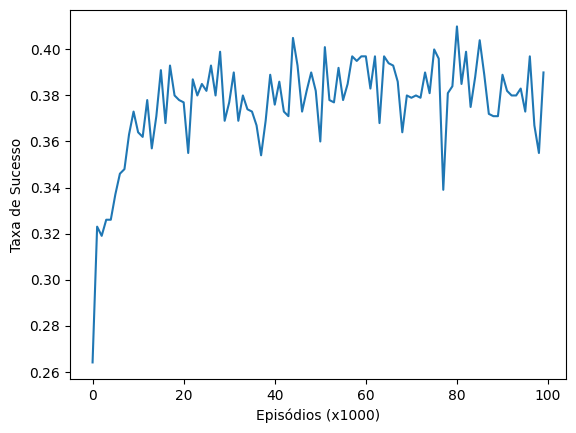

In [21]:
# Plot taxas de sucesso
import matplotlib.pyplot as plt
plt.plot(np.array(taxas_de_sucesso)/1000)
plt.xlabel('Episódios (x1000)')
plt.ylabel('Taxa de Sucesso')
plt.show()

In [22]:
modelo_treinado = ModeloTreinado(
    q_table=q_table,
    n_estados=None,  # Não usado diretamente
    n_acoes=n_acoes,
    taxa_aprendizado=taxa_aprendizado,
    fator_desconto=fator_desconto,
    epsilon=epsilon,
    epsilon_min=epsilon_min,
    taxa_decaimento=taxa_decaimento,
    total_episodios=total_episodios,
    total_passos_max=total_passos_max,
    ambiente=env.spec.id
)

# Avaliação

In [23]:
# 4. AVALIAÇÃO DO AGENTE TREINADO (Versão Segura)
print("\nIniciando avaliação do agente treinado...\n")

# Start with non-visual evaluation first
env_eval = gym.make("Blackjack-v1")
sucessos = 0
derrotas = 0
empates = 0
total_avaliacoes = 50000  # More episodes for better statistics

try:
    q_table_carregada = q_table
    total_passos_max = total_avaliacoes
except:
    # Use the Q-table from the loaded model
    q_table_carregada = modelo_treinado['q_table']
    total_passos_max = modelo_treinado['hiperparametros']['total_passos_max']

print("=== AVALIAÇÃO SEM VISUALIZAÇÃO ===")
for episodio in range(total_avaliacoes):
    estado, info = env_eval.reset()
    finalizado = False

    for passo in range(total_passos_max):
        acao = np.argmax(q_table_carregada[estado, :])
        novo_estado, recompensa, terminado, truncado, info = env_eval.step(acao)
        finalizado = terminado or truncado
        if not finalizado:
            estado = novo_estado
            continue
        
        if recompensa == 1:
            sucessos += 1
            break
        elif recompensa == -1:
            derrotas += 1
            break
        else:
            empates +=1
            break
        

    # Progress indicator
    if (episodio + 1) % 10000 == 0:
        taxa_atual = (sucessos / (episodio + 1)) * 100
        print(f"Episódios: {episodio + 1}/{total_avaliacoes} | Taxa de sucesso: {taxa_atual:.1f}%")

env_eval.close()
print(f"\n📊 RESULTADO FINAL: Taxa de sucesso: {sucessos/total_avaliacoes*100:.2f}% ({sucessos}/{total_avaliacoes})")
print(f"Vitórias: {sucessos}(({sucessos/total_avaliacoes}))")
print(f"Empates: {empates}(({empates/total_avaliacoes}))")
print(f"Derrotas: {derrotas}(({derrotas/total_avaliacoes}))")


Iniciando avaliação do agente treinado...

=== AVALIAÇÃO SEM VISUALIZAÇÃO ===
Episódios: 10000/50000 | Taxa de sucesso: 38.7%
Episódios: 20000/50000 | Taxa de sucesso: 38.8%
Episódios: 30000/50000 | Taxa de sucesso: 38.6%
Episódios: 40000/50000 | Taxa de sucesso: 38.5%
Episódios: 50000/50000 | Taxa de sucesso: 38.6%

📊 RESULTADO FINAL: Taxa de sucesso: 38.57% (19286/50000)
Vitórias: 19286((0.38572))
Empates: 2405((0.0481))
Derrotas: 28309((0.56618))
